<a href="https://colab.research.google.com/github/EmptyRain75/mnist-ai-classifier/blob/main/notebooks/03_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multilayer Perceptron on MNIST

This notebook extends the previous Softmax Regression classifier into a Multilayer Perceptron (MLP).

The previous classifier used a single linear transformation:

```text
Input
  ↓
Flatten
  ↓
Linear
  ↓
10 logits
```

Although Softmax Regression can classify multiple classes, it is still a linear classifier with respect to the original input features.

The MLP introduces a hidden layer and a nonlinear activation function:

```text
Input
  ↓
Flatten
  ↓
Linear
  ↓
ReLU
  ↓
Linear
  ↓
10 logits
```

The purpose of this stage is to study how a hidden nonlinear representation changes the model while reusing the same MNIST dataset, Cross Entropy loss, mini-batch training, and evaluation pipeline.

## Objective

The objectives of this notebook are to:

- Extend Softmax Regression into a one-hidden-layer MLP.
- Understand the role of hidden layers.
- Understand why nonlinear activation functions are necessary.
- Implement the MLP using PyTorch.
- Train and evaluate the model on MNIST.
- Compare the MLP with the previous Softmax Regression classifier.
- Analyze whether the additional model capacity improves classification performance.

The main architectural change is:

```text
Softmax Regression

784
 ↓
Linear
 ↓
10 logits


MLP

784
 ↓
Linear
 ↓
H hidden units
 ↓
ReLU
 ↓
Linear
 ↓
10 logits
```

where `H` is the hidden-layer size.

## Module 1 — Load MNIST

The MLP uses the same MNIST dataset as the previous Softmax Regression model.

Each image has shape:

```text
1 × 28 × 28
```

and represents one digit from `0` to `9`.

We keep the same dataset split:

```text
60,000 training images
        ↓
50,000 training
10,000 validation

10,000 test images
```

The `DataLoader` handles mini-batch creation and shuffling.

Unlike the model architecture, the data pipeline does not need to change when moving from Softmax Regression to an MLP.

The images will later be flattened from:

```text
(batch_size, 1, 28, 28)
```

to:

```text
(batch_size, 784)
```

before being passed into the MLP.

In [1]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


torch.manual_seed(42)

transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)


train_dataset, val_dataset = random_split(
    full_train_dataset,
    [50000, 10000],
    generator=torch.Generator().manual_seed(42)
)


batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(42)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.41MB/s]


Training samples: 50000
Validation samples: 10000
Test samples: 10000


## Module 2 — Define the MLP

The previous Softmax Regression model used only one linear layer:

```text
784 inputs
   ↓
Linear
   ↓
10 logits
```

The MLP introduces a hidden layer and a nonlinear activation function:

```text
784 inputs
   ↓
Linear
   ↓
H hidden units
   ↓
ReLU
   ↓
Linear
   ↓
10 logits
```

For this notebook, we use:

```text
H = 128
```

so the architecture becomes:

```text
784
 ↓
Linear(784 → 128)
 ↓
ReLU
 ↓
Linear(128 → 10)
 ↓
10 logits
```

The hidden layer allows the model to learn an intermediate representation of the input.

The ReLU activation is necessary because stacking only linear layers would still be equivalent to a single linear transformation.

The forward equations are:

$$
Z_1 = XW_1 + b_1
$$

$$
H = \text{ReLU}(Z_1)
$$

$$
Z_2 = HW_2 + b_2
$$

where:

- $Z_1$ is the hidden-layer pre-activation.
- $H$ is the hidden representation after ReLU.
- $Z_2$ contains the final 10 logits.

In [2]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [3]:
model = MLP()

print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Module 3 — Loss and Optimizer

The MLP still performs multiclass classification over the same 10 MNIST classes.

Therefore, the loss function remains:

```text
Cross Entropy
```

and we continue using:

```python
nn.CrossEntropyLoss()
```

The final layer of the MLP outputs 10 logits:

```text
(batch_size, 10)
```

These logits are passed directly into `CrossEntropyLoss`.

We do **not** apply Softmax manually before the loss because PyTorch's `CrossEntropyLoss` already handles the required transformation internally.

For optimization, we continue using Stochastic Gradient Descent (SGD):

```text
parameters
   ↓
gradients
   ↓
SGD update
```

The difference from Softmax Regression is that the optimizer now updates parameters from **both linear layers** instead of only one.

In [4]:
criterion = nn.CrossEntropyLoss()

learning_rate = 0.1

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

## Module 4 — Training Loop

The training loop follows the same PyTorch workflow used for Softmax Regression:

```text
Mini-batch
   ↓
Forward pass
   ↓
Compute loss
   ↓
Clear old gradients
   ↓
Backpropagation
   ↓
Parameter update
```

The important difference is that backpropagation now passes through the full MLP:

```text
Loss
 ↓
fc2
 ↓
ReLU
 ↓
fc1
```

PyTorch automatically computes the gradients for all trainable parameters using autograd.

The training sequence is:

```python
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

where:

- `zero_grad()` clears gradients from the previous iteration.
- `backward()` computes gradients through the computational graph.
- `step()` updates the model parameters.

In [5]:
import time


def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    n_epochs=10
):
    loss_history = []

    start_time = time.perf_counter()

    model.train()

    for epoch in range(n_epochs):
        epoch_loss = 0.0

        for images, labels in train_loader:

            # Forward pass
            logits = model(images)

            # Compute loss
            loss = criterion(logits, labels)

            # Clear old gradients
            optimizer.zero_grad()

            # Backpropagation
            loss.backward()

            # Update parameters
            optimizer.step()

            epoch_loss += loss.item()

        average_loss = epoch_loss / len(train_loader)
        loss_history.append(average_loss)

        print(
            f"Epoch {epoch + 1}/{n_epochs} | "
            f"Loss: {average_loss:.4f}"
        )

    training_time = time.perf_counter() - start_time

    return loss_history, training_time

In [6]:
n_epochs = 10

loss_history, training_time = train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    n_epochs=n_epochs
)

Epoch 1/10 | Loss: 0.3700
Epoch 2/10 | Loss: 0.1746
Epoch 3/10 | Loss: 0.1250
Epoch 4/10 | Loss: 0.0967
Epoch 5/10 | Loss: 0.0798
Epoch 6/10 | Loss: 0.0667
Epoch 7/10 | Loss: 0.0561
Epoch 8/10 | Loss: 0.0483
Epoch 9/10 | Loss: 0.0425
Epoch 10/10 | Loss: 0.0369


## Module 5 — Evaluation

After training, the model is evaluated without updating its parameters.

During evaluation, we use:

```python
model.eval()
```

to switch the model to evaluation mode, and:

```python
with torch.no_grad():
```

to disable gradient tracking.

For each mini-batch:

```text
Images
  ↓
MLP
  ↓
10 logits
  ↓
argmax
  ↓
Predicted class
```

The predicted class is the index of the largest logit:

```python
predictions = torch.argmax(logits, dim=1)
```

Accuracy is then computed as:

$$
\text{Accuracy}
=
\frac{\text{Number of correct predictions}}
{\text{Total number of predictions}}
$$

We evaluate the model on:

- Training set
- Validation set
- Test set

The validation set is useful for analyzing model behavior and choosing hyperparameters.

The test set is reserved for the final evaluation of the trained model.

In [7]:
def evaluate(model, data_loader):
    correct = 0
    total = 0

    model.eval()

    with torch.no_grad():
        for images, labels in data_loader:

            logits = model(images)

            predictions = torch.argmax(
                logits,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return correct / total

In [8]:
train_accuracy = evaluate(
    model,
    train_loader
)

val_accuracy = evaluate(
    model,
    val_loader
)

test_accuracy = evaluate(
    model,
    test_loader
)


print(f"Training time      : {training_time:.2f} s")
print(f"Training accuracy  : {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Test accuracy      : {test_accuracy:.4f}")

Training time      : 80.17 s
Training accuracy  : 0.9897
Validation accuracy: 0.9711
Test accuracy      : 0.9744


## Module 6 — Experiments

Softmax Regression had no hidden layer, so one of the most important new hyperparameters introduced by the MLP is the **hidden-layer size**.

The hidden size determines the dimensionality of the learned intermediate representation:

```text
784
 ↓
Linear
 ↓
H hidden units
 ↓
ReLU
 ↓
Linear
 ↓
10
```

Increasing `H` increases the number of trainable parameters and therefore increases the capacity of the model.

However, a larger hidden layer does not automatically guarantee better validation performance.

In this experiment, we compare:

```text
H = 32
H = 128
H = 512
```

while keeping the following settings fixed:

```text
Learning rate = 0.1
Batch size    = 32
Epochs        = 10
Optimizer     = SGD
Activation    = ReLU
```

For each model, we record:

- Number of trainable parameters
- Training accuracy
- Validation accuracy
- Training time

This allows us to study the relationship between model capacity and generalization.

In [9]:
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

In [10]:
def create_train_loader(batch_size=32, seed=42):
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

In [11]:
hidden_sizes = [32, 128, 512]

experiment_results = []

for hidden_size in hidden_sizes:

    torch.manual_seed(42)

    experiment_model = MLP(
        hidden_size=hidden_size
    )

    experiment_optimizer = torch.optim.SGD(
        experiment_model.parameters(),
        lr=0.1
    )

    experiment_train_loader = create_train_loader(
        batch_size=32,
        seed=42
    )

    print(
        f"\nHidden size: {hidden_size}"
    )

    loss_history, experiment_time = train_model(
        experiment_model,
        experiment_train_loader,
        criterion,
        experiment_optimizer,
        n_epochs=10
    )

    train_acc = evaluate(
        experiment_model,
        experiment_train_loader
    )

    val_acc = evaluate(
        experiment_model,
        val_loader
    )

    parameter_count = count_parameters(
        experiment_model
    )

    experiment_results.append({
        "hidden_size": hidden_size,
        "parameters": parameter_count,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "training_time": experiment_time
    })


Hidden size: 32
Epoch 1/10 | Loss: 0.3975
Epoch 2/10 | Loss: 0.2122
Epoch 3/10 | Loss: 0.1640
Epoch 4/10 | Loss: 0.1363
Epoch 5/10 | Loss: 0.1192
Epoch 6/10 | Loss: 0.1061
Epoch 7/10 | Loss: 0.0966
Epoch 8/10 | Loss: 0.0889
Epoch 9/10 | Loss: 0.0831
Epoch 10/10 | Loss: 0.0780

Hidden size: 128
Epoch 1/10 | Loss: 0.3700
Epoch 2/10 | Loss: 0.1746
Epoch 3/10 | Loss: 0.1250
Epoch 4/10 | Loss: 0.0967
Epoch 5/10 | Loss: 0.0798
Epoch 6/10 | Loss: 0.0667
Epoch 7/10 | Loss: 0.0561
Epoch 8/10 | Loss: 0.0483
Epoch 9/10 | Loss: 0.0425
Epoch 10/10 | Loss: 0.0369

Hidden size: 512
Epoch 1/10 | Loss: 0.3571
Epoch 2/10 | Loss: 0.1605
Epoch 3/10 | Loss: 0.1118
Epoch 4/10 | Loss: 0.0847
Epoch 5/10 | Loss: 0.0685
Epoch 6/10 | Loss: 0.0553
Epoch 7/10 | Loss: 0.0459
Epoch 8/10 | Loss: 0.0384
Epoch 9/10 | Loss: 0.0325
Epoch 10/10 | Loss: 0.0276


In [12]:
for result in experiment_results:

    print(
        f"Hidden size: {result['hidden_size']}"
    )

    print(
        f"Parameters: {result['parameters']}"
    )

    print(
        f"Train accuracy: "
        f"{result['train_accuracy']:.4f}"
    )

    print(
        f"Validation accuracy: "
        f"{result['val_accuracy']:.4f}"
    )

    print(
        f"Training time: "
        f"{result['training_time']:.2f} s"
    )

    print()

Hidden size: 32
Parameters: 25450
Train accuracy: 0.9770
Validation accuracy: 0.9582
Training time: 76.61 s

Hidden size: 128
Parameters: 101770
Train accuracy: 0.9897
Validation accuracy: 0.9711
Training time: 77.27 s

Hidden size: 512
Parameters: 407050
Train accuracy: 0.9945
Validation accuracy: 0.9750
Training time: 94.12 s



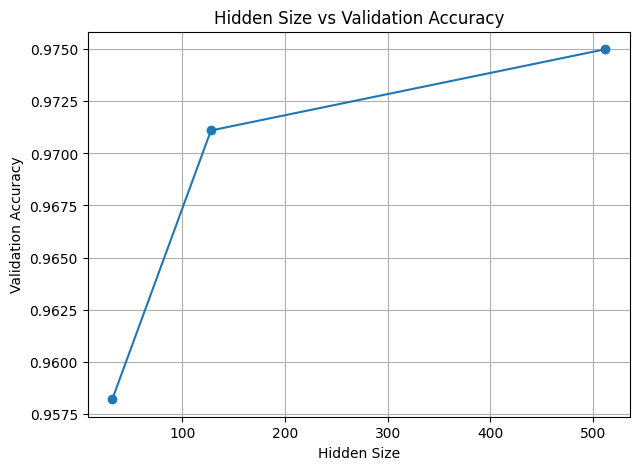

In [13]:
import matplotlib.pyplot as plt


sizes = [
    result["hidden_size"]
    for result in experiment_results
]

val_accuracies = [
    result["val_accuracy"]
    for result in experiment_results
]


plt.figure(figsize=(7, 5))

plt.plot(
    sizes,
    val_accuracies,
    marker="o"
)

plt.xlabel("Hidden Size")
plt.ylabel("Validation Accuracy")
plt.title(
    "Hidden Size vs Validation Accuracy"
)

plt.grid()

plt.show()

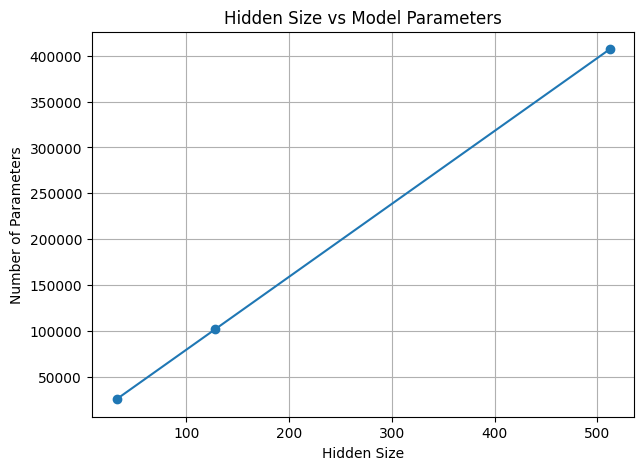

In [14]:
parameter_counts = [
    result["parameters"]
    for result in experiment_results
]


plt.figure(figsize=(7, 5))

plt.plot(
    sizes,
    parameter_counts,
    marker="o"
)

plt.xlabel("Hidden Size")
plt.ylabel("Number of Parameters")
plt.title(
    "Hidden Size vs Model Parameters"
)

plt.grid()

plt.show()

### Hidden-Size Experiment Analysis

The validation accuracies obtained were:

```text
H = 32  → 0.9582
H = 128 → 0.9711
H = 512 → 0.9750
```

Increasing the hidden-layer size improved validation accuracy in this experiment.

The improvement from `H = 32` to `H = 128` was relatively large, increasing validation accuracy from `95.82%` to `97.11%`.

Increasing the hidden size further to `H = 512` improved validation accuracy to `97.50%`, but the improvement was smaller.

This suggests that increasing the hidden-layer size gives the model greater capacity to learn useful nonlinear representations, but the improvement does not scale proportionally with the number of hidden units.

```text
32 → 128
large accuracy improvement

128 → 512
smaller accuracy improvement
```

Therefore, the experiment shows a trade-off between model capacity and efficiency. A larger hidden layer can improve performance, but it also introduces substantially more trainable parameters and computational cost for progressively smaller gains in validation accuracy.

No clear conclusion about overfitting can be made from validation accuracy alone. The training accuracy should also be compared with validation accuracy to determine whether larger models are fitting the training data substantially more strongly.

### Experiment 2 — Effect of Network Depth

The previous experiment changed the **width** of the MLP by varying the number of hidden units.

This experiment changes the **depth** of the network by varying the number of hidden layers.

We compare:

```text
1 hidden layer
784 → 128 → 10

2 hidden layers
784 → 128 → 64 → 10

3 hidden layers
784 → 128 → 64 → 32 → 10
```

Each hidden layer is followed by a ReLU activation.

Increasing depth allows the network to compose multiple nonlinear transformations:

```text
Input
  ↓
Representation 1
  ↓
Representation 2
  ↓
Representation 3
  ↓
Output
```

A deeper network can represent more complex functions, but greater depth does not automatically guarantee better validation performance.

For fairness, we keep the following settings fixed:

```text
Learning rate = 0.1
Batch size    = 32
Epochs        = 10
Optimizer     = SGD
Activation    = ReLU
```

For each architecture, we record:

- Number of hidden layers
- Number of trainable parameters
- Training accuracy
- Validation accuracy
- Training time

In [15]:
class DeepMLP(nn.Module):
    def __init__(
        self,
        hidden_sizes,
        input_size=784,
        num_classes=10
    ):
        super().__init__()

        layers = []

        previous_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(
                nn.Linear(previous_size, hidden_size)
            )

            layers.append(
                nn.ReLU()
            )

            previous_size = hidden_size

        layers.append(
            nn.Linear(previous_size, num_classes)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        return self.network(x)

In [16]:
# quick check
model_1 = DeepMLP([128])
model_2 = DeepMLP([128, 64])
model_3 = DeepMLP([128, 64, 32])

print("1 hidden layer:")
print(model_1)

print("\n2 hidden layers:")
print(model_2)

print("\n3 hidden layers:")
print(model_3)

1 hidden layer:
DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

2 hidden layers:
DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

3 hidden layers:
DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [17]:
architectures = [
    {
        "name": "1 hidden layer",
        "hidden_sizes": [128]
    },
    {
        "name": "2 hidden layers",
        "hidden_sizes": [128, 64]
    },
    {
        "name": "3 hidden layers",
        "hidden_sizes": [128, 64, 32]
    }
]


depth_results = []

for architecture in architectures:

    torch.manual_seed(42)

    experiment_model = DeepMLP(
        architecture["hidden_sizes"]
    )

    experiment_optimizer = torch.optim.SGD(
        experiment_model.parameters(),
        lr=0.1
    )

    experiment_train_loader = create_train_loader(
        batch_size=32,
        seed=42
    )

    print(
        f"\n{architecture['name']}"
    )

    loss_history, experiment_time = train_model(
        experiment_model,
        experiment_train_loader,
        criterion,
        experiment_optimizer,
        n_epochs=10
    )

    train_acc = evaluate(
        experiment_model,
        experiment_train_loader
    )

    val_acc = evaluate(
        experiment_model,
        val_loader
    )

    parameter_count = count_parameters(
        experiment_model
    )

    depth_results.append({
        "name": architecture["name"],
        "hidden_sizes": architecture["hidden_sizes"],
        "parameters": parameter_count,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "training_time": experiment_time
    })


1 hidden layer
Epoch 1/10 | Loss: 0.3700
Epoch 2/10 | Loss: 0.1746
Epoch 3/10 | Loss: 0.1250
Epoch 4/10 | Loss: 0.0967
Epoch 5/10 | Loss: 0.0798
Epoch 6/10 | Loss: 0.0667
Epoch 7/10 | Loss: 0.0561
Epoch 8/10 | Loss: 0.0483
Epoch 9/10 | Loss: 0.0425
Epoch 10/10 | Loss: 0.0369

2 hidden layers
Epoch 1/10 | Loss: 0.3966
Epoch 2/10 | Loss: 0.1454
Epoch 3/10 | Loss: 0.0979
Epoch 4/10 | Loss: 0.0746
Epoch 5/10 | Loss: 0.0609
Epoch 6/10 | Loss: 0.0475
Epoch 7/10 | Loss: 0.0383
Epoch 8/10 | Loss: 0.0313
Epoch 9/10 | Loss: 0.0266
Epoch 10/10 | Loss: 0.0207

3 hidden layers
Epoch 1/10 | Loss: 0.4966
Epoch 2/10 | Loss: 0.1440
Epoch 3/10 | Loss: 0.0991
Epoch 4/10 | Loss: 0.0752
Epoch 5/10 | Loss: 0.0614
Epoch 6/10 | Loss: 0.0492
Epoch 7/10 | Loss: 0.0371
Epoch 8/10 | Loss: 0.0342
Epoch 9/10 | Loss: 0.0280
Epoch 10/10 | Loss: 0.0260


In [18]:
for result in depth_results:

    print(result["name"])

    print(
        "Hidden sizes:",
        result["hidden_sizes"]
    )

    print(
        "Parameters:",
        result["parameters"]
    )

    print(
        f"Train accuracy: "
        f"{result['train_accuracy']:.4f}"
    )

    print(
        f"Validation accuracy: "
        f"{result['val_accuracy']:.4f}"
    )

    print(
        f"Training time: "
        f"{result['training_time']:.2f} s"
    )

    print()

1 hidden layer
Hidden sizes: [128]
Parameters: 101770
Train accuracy: 0.9897
Validation accuracy: 0.9711
Training time: 81.75 s

2 hidden layers
Hidden sizes: [128, 64]
Parameters: 109386
Train accuracy: 0.9949
Validation accuracy: 0.9718
Training time: 78.94 s

3 hidden layers
Hidden sizes: [128, 64, 32]
Parameters: 111146
Train accuracy: 0.9920
Validation accuracy: 0.9710
Training time: 82.24 s



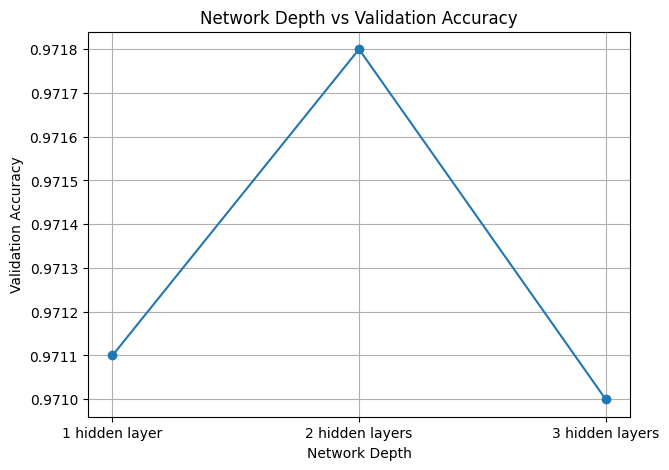

In [19]:
depth_names = [
    result["name"]
    for result in depth_results
]

depth_val_accuracies = [
    result["val_accuracy"]
    for result in depth_results
]


plt.figure(figsize=(7, 5))

plt.plot(
    depth_names,
    depth_val_accuracies,
    marker="o"
)

plt.xlabel("Network Depth")
plt.ylabel("Validation Accuracy")
plt.title(
    "Network Depth vs Validation Accuracy"
)

plt.grid()

plt.show()

### Depth Experiment Analysis

The results were:

```text
1 hidden layer
Train accuracy      = 0.9897
Validation accuracy = 0.9711
Parameters          = 101,770

2 hidden layers
Train accuracy      = 0.9949
Validation accuracy = 0.9718
Parameters          = 109,386

3 hidden layers
Train accuracy      = 0.9920
Validation accuracy = 0.9710
Parameters          = 111,146
```

Adding a second hidden layer increased the training accuracy from `98.97%` to `99.49%`, showing that the deeper model had enough capacity to fit the training data more strongly.

However, the validation accuracy increased only slightly:

```text
97.11% → 97.18%
```

Therefore, the additional depth produced only a very small improvement in generalization despite increasing the model's capacity.

Increasing the depth further to three hidden layers did not improve performance. The validation accuracy decreased slightly to `97.10%`, while the training accuracy also decreased to `99.20%`.

This experiment shows that increasing network depth does not automatically improve classification performance.

```text
More depth
   ↓
More nonlinear transformations
   ↓
Potentially greater representational capacity
```

but the additional capacity must still be successfully optimized and must learn features that generalize to unseen data.

The gap between training and validation accuracy was largest for the two-hidden-layer model:

```text
Training   = 99.49%
Validation = 97.18%
```

This suggests that the additional capacity allowed the model to fit the training data more strongly, while providing only a small improvement on the validation set.

The three-hidden-layer model also demonstrates that simply adding more layers is not sufficient. Performance depends on factors such as architecture, optimization, initialization, learning rate, and training duration.

Under the current configuration, increasing depth beyond one hidden layer provided little improvement in validation accuracy.

## Module 7 — Softmax Regression vs MLP

The main purpose of the MLP stage is to address a limitation of Softmax Regression.

Softmax Regression uses a single linear transformation:

```text
784
 ↓
Linear
 ↓
10 logits
```

The MLP introduces a hidden nonlinear representation:

```text
784
 ↓
Linear
 ↓
128
 ↓
ReLU
 ↓
Linear
 ↓
10 logits
```

The main architectural difference is therefore:

```text
Softmax Regression
X
 ↓
Linear
 ↓
logits


MLP
X
 ↓
Linear
 ↓
hidden representation
 ↓
ReLU
 ↓
Linear
 ↓
logits
```

The dataset, mini-batch training pipeline, Cross Entropy loss, optimizer concept, and evaluation procedure remain largely unchanged.

The key change is the addition of:

```text
Hidden layer
+
Nonlinear activation
```

which allows the model to learn a nonlinear transformation of the original pixel features.

### Validation Accuracy Comparison

Using the previous Softmax Regression result and the one-hidden-layer MLP:

| Model | Architecture | Validation Accuracy |
|---|---|---:|
| Softmax Regression | `784 → 10` | 0.9205 |
| MLP | `784 → 128 → 10` | 0.9711 |

The MLP improved validation accuracy from:

```text
92.05%
   ↓
97.11%
```

which is an improvement of approximately:

```text
+5.06 percentage points
```

### Analysis

The MLP achieved substantially higher validation accuracy than Softmax Regression:

```text
Softmax Regression = 92.05%
MLP                = 97.11%
```

Both models receive the same flattened MNIST input and produce 10 output logits.

The important difference is the internal representation.

Softmax Regression maps the original pixel values directly to class logits using one linear transformation:

```text
pixels
  ↓
linear class scores
```

The MLP first transforms the pixels into a learned hidden representation:

```text
pixels
  ↓
hidden representation
  ↓
nonlinear transformation
  ↓
class logits
```

Because Softmax Regression is a linear classifier with respect to the original input features, its decision boundaries are limited to linear separation in the input space.

The MLP introduces ReLU between linear layers, so the complete model can represent nonlinear decision boundaries.

The improvement in validation accuracy therefore demonstrates the practical benefit of adding nonlinear representation capacity for MNIST.

However, this additional capacity also introduces:

- More trainable parameters
- More computation
- More hyperparameters
- Greater potential for overfitting

The transition can therefore be summarized as:

```text
Softmax Regression
simple
linear
lower capacity
        ↓
add hidden layer + ReLU
        ↓
MLP
nonlinear
higher capacity
better MNIST performance
```

## Conclusion

This notebook extended the previous Softmax Regression classifier into a Multilayer Perceptron (MLP).

The Softmax Regression model used a single linear transformation:

```text
784
 ↓
Linear
 ↓
10 logits
```

The MLP introduced a hidden layer and a nonlinear activation function:

```text
784
 ↓
Linear
 ↓
128
 ↓
ReLU
 ↓
Linear
 ↓
10 logits
```

The main architectural change was therefore the addition of a learned nonlinear representation.

### What was reused

Several parts of the previous pipeline remained unchanged:

```text
MNIST dataset
Flattening
Mini-batch training
Cross Entropy loss
SGD optimizer
Train / validation / test split
Accuracy-based evaluation
```

This shows that moving from Softmax Regression to an MLP does not require rebuilding the complete classification pipeline.

### What changed

The representation and model modules changed:

```text
Softmax Regression

Input
 ↓
Linear
 ↓
Output


MLP

Input
 ↓
Linear
 ↓
Hidden representation
 ↓
ReLU
 ↓
Linear
 ↓
Output
```

The ReLU activation is important because multiple linear layers without a nonlinear activation would still be equivalent to a single linear transformation.

By introducing nonlinear transformations, the MLP can represent more complex decision boundaries than Softmax Regression.

### Experimental observations

The hidden-size experiment showed that increasing model width improved validation accuracy:

```text
H = 32  → 95.82%
H = 128 → 97.11%
H = 512 → 97.50%
```

However, the improvement became smaller as the hidden size increased, demonstrating diminishing returns from additional model capacity.

The depth experiment produced:

```text
1 hidden layer  → 97.11%
2 hidden layers → 97.18%
3 hidden layers → 97.10%
```

Adding a second hidden layer allowed the model to fit the training data more strongly, but produced only a very small improvement in validation accuracy.

Adding a third hidden layer did not improve validation performance.

These experiments show that increasing width or depth does not automatically produce proportional improvements in generalization.

### Softmax Regression vs MLP

The one-hidden-layer MLP achieved substantially better validation accuracy than the previous Softmax Regression model:

```text
Softmax Regression → 92.05%
MLP                → 97.11%
```

This improvement demonstrates the practical benefit of adding a nonlinear hidden representation.

The transition can be summarized as:

```text
Softmax Regression
Linear classifier
Lower capacity
      ↓
Add hidden layer
Add ReLU
      ↓
MLP
Nonlinear classifier
Higher capacity
```

### Remaining limitation

Although the MLP improves classification performance, the MNIST image is still flattened:

```text
28 × 28 image
     ↓
784-dimensional vector
```

This means the model does not explicitly use the two-dimensional spatial structure of the image.

For example, the MLP has no built-in knowledge that neighboring pixels are spatially related.

The next stage will address this limitation using a Convolutional Neural Network (CNN), which processes images while preserving and exploiting their spatial structure.

```text
Softmax Regression
Linear classification
        ↓
MLP
Nonlinear representation
        ↓
CNN
Spatial representation
```